In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

# SimpleImputer - Most Frequent Strategy

## Objective
Replace missing values in categorical features with the most frequently occurring category (mode).

## Why?
Machine learning algorithms cannot handle missing values directly. The most frequent category is used as a reasonable estimate for missing categorical values.

## Suitable For
- Categorical variables
- Nominal features
- Ordinal features

## Advantages
- Simple and fast.
- Easy to implement.
- Preserves existing categories.
- Supported directly by Scikit-learn.

## Disadvantages
- Can increase the frequency of the majority class.
- May introduce bias if many values are missing.
- Does not preserve the original distribution when missing values are large.

## Example
Embarked:
S, C, S, NaN, S

After Imputation:
S, C, S, S, S

In [5]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer

In [7]:
df1 = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

In [8]:
df1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
categorical_features = df1.select_dtypes(include='object')

categorical_features.isnull().sum()

Name          0
Sex           0
Ticket        0
Cabin       687
Embarked      2
dtype: int64

In [10]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [11]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: object

In [12]:
imputer = SimpleImputer(strategy='most_frequent')

In [13]:
df['Embarked'] = imputer.fit_transform(df[['Embarked']]).ravel()

In [14]:
df['Embarked'].isnull().sum()

np.int64(0)

In [15]:
df_original = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

print(df_original['Embarked'].value_counts(dropna=False))

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


In [18]:
print(df['Embarked'].value_counts(dropna=False))

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


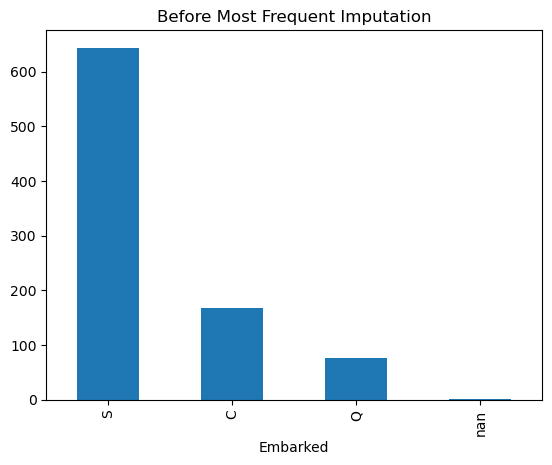

In [19]:
import matplotlib.pyplot as plt

df_original['Embarked'].value_counts(dropna=False).plot(kind='bar')
plt.title("Before Most Frequent Imputation")
plt.show()

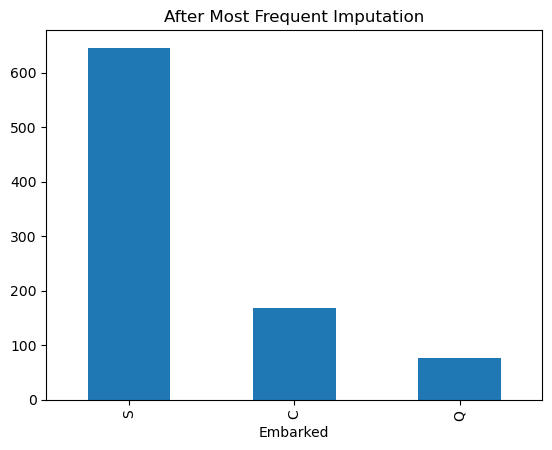

In [20]:
df['Embarked'].value_counts(dropna=False).plot(kind='bar')
plt.title("After Most Frequent Imputation")
plt.show()

# Handling Missing Values - Creating a New Category

## Objective
Replace missing values in categorical features with a new category called "Missing".

## Why?
Sometimes the missing value itself contains useful information. Instead of guessing an existing category, we explicitly mark it as "Missing".

## Suitable For
- Categorical Variables
- Features where missingness itself may carry information

In [21]:
import pandas as pd

df2 = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

In [22]:
df2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
df2['Cabin'].isnull().sum()

np.int64(687)

In [24]:
df2['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [26]:
df2['Cabin'] = df2['Cabin'].fillna('Missing')

In [27]:
df2['Cabin'].isnull().sum()

np.int64(0)

In [28]:
df2['Cabin'].value_counts()

Cabin
Missing        687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

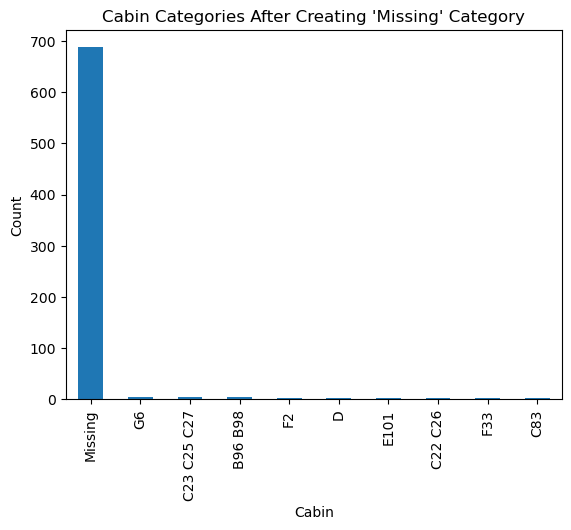

In [29]:
import matplotlib.pyplot as plt

df2['Cabin'].value_counts().head(10).plot(kind='bar')
plt.title("Cabin Categories After Creating 'Missing' Category")
plt.xlabel("Cabin")
plt.ylabel("Count")
plt.show()

# Handling Missing Values - Random Sample Imputation

## Objective
Replace missing values by randomly selecting existing values from the same feature.

## Why?
Unlike mean, median, or mode imputation, random sample imputation helps preserve the original distribution and variance of the data.

## Suitable For
- Numerical Variables
- Categorical Variables

In [30]:
import pandas as pd
import numpy as np

In [31]:
df3 = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

In [32]:
df3['Age'].isnull().sum()

np.int64(177)

In [33]:
df_random = df3.copy()

In [34]:
def random_imputation(variable):
    
    random_sample = df_random[variable].dropna().sample(
        df_random[variable].isnull().sum(),
        random_state=0
    )
    
    random_sample.index = df_random[df_random[variable].isnull()].index
    
    df_random.loc[df_random[variable].isnull(), variable] = random_sample

In [35]:
random_imputation('Age')

In [36]:
df_random['Age'].isnull().sum()

np.int64(0)

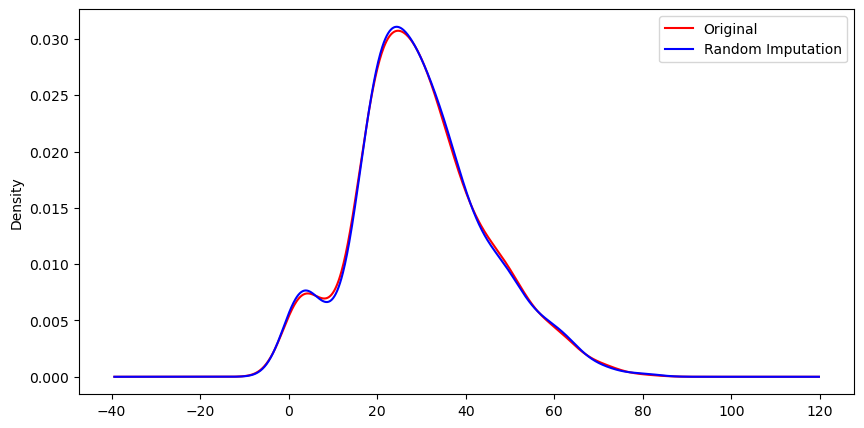

In [37]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)

df['Age'].plot(kind='kde', ax=ax, color='red', label='Original')

df_random['Age'].plot(kind='kde', ax=ax, color='blue', label='Random Imputation')

plt.legend()
plt.show()

In [38]:
print("Original Variance :", df['Age'].var())

print("Random Imputation Variance :", df_random['Age'].var())

Original Variance : 211.0191247463081
Random Imputation Variance : 212.10002044061116


# Handling Missing Values - Missing Indicator

## Objective
Create a new binary feature that indicates whether a value was originally missing.

## Why?
Sometimes the fact that a value is missing itself contains useful information. Instead of only filling the missing value, we also inform the model that the value was originally missing.

## Suitable For
- Numerical Variables
- Categorical Variables

In [39]:
import pandas as pd

from sklearn.impute import SimpleImputer

In [40]:
df4 = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

In [41]:
df4['Age'].isnull().sum()

np.int64(177)

In [42]:
imputer = SimpleImputer(
    strategy='median',
    add_indicator=True
)

In [43]:
imputed_data = imputer.fit_transform(df[['Age']])

In [44]:
imputed_data

array([[22.,  0.],
       [38.,  0.],
       [26.,  0.],
       ...,
       [28.,  1.],
       [26.,  0.],
       [32.,  0.]])

In [45]:
df_indicator = pd.DataFrame(
    imputed_data,
    columns=['Age', 'Age_missing']
)

df_indicator.head()

,Age,Age_missing
0,22.0,0.0
1,38.0,0.0
2,26.0,0.0
3,35.0,0.0
4,35.0,0.0


In [46]:
df_indicator.head(10)

,Age,Age_missing
0,22.0,0.0
1,38.0,0.0
2,26.0,0.0
3,35.0,0.0
4,35.0,0.0
5,28.0,1.0
6,54.0,0.0
7,2.0,0.0
8,27.0,0.0
9,14.0,0.0


In [47]:
df_indicator['Age_missing'].value_counts()

Age_missing
0.0    714
1.0    177
Name: count, dtype: int64

In [50]:
df4['Age_missing'] = df4['Age'].isnull().astype(int)

In [51]:
df4['Age'] = df4['Age'].fillna(df4['Age'].median())

# Handling Missing Values - Automatic Imputation using SimpleImputer

## Objective
Automatically replace missing values using predefined imputation strategies provided by Scikit-learn.

## Why?
Instead of manually using `fillna()` for each column, `SimpleImputer` provides a reusable and efficient approach for handling missing values. It is especially useful when building machine learning pipelines.

## Available Strategies
- Mean
- Median
- Most Frequent
- Constant

## Suitable For
- Numerical Variables
- Categorical Variables

In [52]:
import pandas as pd

from sklearn.impute import SimpleImputer

In [53]:
df = pd.read_csv(r"C:\Users\Raksha\Downloads\titanic\train.csv")

In [54]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [55]:
numerical_features = ['Age']

categorical_features = ['Embarked']

In [57]:
median_imputer = SimpleImputer(strategy='median')

In [58]:
mode_imputer = SimpleImputer(strategy='most_frequent')

In [59]:
df[numerical_features] = median_imputer.fit_transform(df[numerical_features])

df[categorical_features] = mode_imputer.fit_transform(df[categorical_features])

In [60]:
df[numerical_features].isnull().sum()

Age    0
dtype: int64

In [61]:
df[categorical_features].isnull().sum()

Embarked    0
dtype: int64

In [62]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64